In [1]:
###-----------------
### Import libraries
###-----------------

from pathlib import Path  # Import Path for file system path operations and management
import numpy as np  # Import NumPy for numerical computations and array operations
import pandas as pd  # Import Pandas for data manipulation and analysis with DataFrames
import matplotlib.pyplot as plt  # Import Matplotlib for creating static, interactive visualizations
import seaborn as sns  # Import Seaborn for statistical data visualization built on Matplotlib

from sklearn.model_selection import train_test_split  # Import function to split dataset into training and testing subsets
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, mean_squared_error,r2_score  # Import function to calculate various metric

from collections.abc import Callable  # Type hinting callable objects/functions
from typing import Literal  # Literal type hints to restrict variable values

from sklearn.preprocessing import StandardScaler  # Import for standardizing features (zero mean, unit variance)

from utils.helper import fn_plot_tf_hist, fn_plot_confusion_matrix, fn_plot_label# Custom utility

import tensorflow as tf

In [2]:
###----------------------
### Some basic parameters
###----------------------

inpDir = Path('..') / '..' / 'input'
outDir = Path('..') / 'output'
modelDir = Path('..') / 'models'

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
tf.random.set_seed(RANDOM_STATE) # setting for Tensorflow as well

TEST_SIZE = 0.2

ALPHA = 0.001
EPOCHS = 100# number of cycles to run
PATIENCE = 20
LR_PATIENCE = 15
FACTOR_LR = 0.1
BATCH_SIZE = 32 # inline of Training Rows being 60000
IMG_HEIGHT = 190
IMG_WIDTH = 190
LR_FACTOR  = 0.1
MIN_LR = 1e-5

# Set parameters for decoration of plots
params = {'legend.fontsize' : 'large',
          'figure.figsize'  : (15,10),
          'axes.labelsize'  : 'x-large',
          'axes.titlesize'  :'x-large',
          'xtick.labelsize' :'large',
          'ytick.labelsize' :'large',
         }

CMAP = plt.cm.coolwarm

plt.rcParams.update(params) # update rcParams

plt.style.use('seaborn-v0_8-darkgrid') # plt.style.use('ggplot')

<h1>Getting Weather dataset</h1>

In [3]:
data_df = pd.read_csv('weatherHistory.csv')
data_df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [4]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


In [5]:
#unique value for every columns
for col in data_df.columns:
    print(f'Col : {col} -- {data_df[col].unique()}')

Col : Formatted Date -- ['2006-04-01 00:00:00.000 +0200' '2006-04-01 01:00:00.000 +0200'
 '2006-04-01 02:00:00.000 +0200' ... '2016-09-09 21:00:00.000 +0200'
 '2016-09-09 22:00:00.000 +0200' '2016-09-09 23:00:00.000 +0200']
Col : Summary -- ['Partly Cloudy' 'Mostly Cloudy' 'Overcast' 'Foggy'
 'Breezy and Mostly Cloudy' 'Clear' 'Breezy and Partly Cloudy'
 'Breezy and Overcast' 'Humid and Mostly Cloudy' 'Humid and Partly Cloudy'
 'Windy and Foggy' 'Windy and Overcast' 'Breezy and Foggy'
 'Windy and Partly Cloudy' 'Breezy' 'Dry and Partly Cloudy'
 'Windy and Mostly Cloudy' 'Dangerously Windy and Partly Cloudy' 'Dry'
 'Windy' 'Humid and Overcast' 'Light Rain' 'Drizzle' 'Windy and Dry'
 'Dry and Mostly Cloudy' 'Breezy and Dry' 'Rain']
Col : Precip Type -- ['rain' 'snow' nan]
Col : Temperature (C) -- [ 9.47222222  9.35555556  9.37777778 ... 28.47222222 28.33888889
 30.60555556]
Col : Apparent Temperature (C) -- [ 7.38888889  7.22777778  9.37777778 ... 12.14444444  9.73888889
  9.23333333]
Co

In [6]:
data_df['datetime'] = pd.to_datetime(data_df['Formatted Date'], utc = True)
data_df

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary,datetime
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.,2006-03-31 22:00:00+00:00
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.,2006-03-31 23:00:00+00:00
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.,2006-04-01 00:00:00+00:00
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.,2006-04-01 01:00:00+00:00
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.,2006-04-01 02:00:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
96448,2016-09-09 19:00:00.000 +0200,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.,2016-09-09 17:00:00+00:00
96449,2016-09-09 20:00:00.000 +0200,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.,2016-09-09 18:00:00+00:00
96450,2016-09-09 21:00:00.000 +0200,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.,2016-09-09 19:00:00+00:00
96451,2016-09-09 22:00:00.000 +0200,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.,2016-09-09 20:00:00+00:00


In [7]:
temp_df = data_df[['datetime','Temperature (C)']]
temp_df = temp_df.sort_values('datetime',axis = 0,ascending=True)
temp_df = temp_df.reset_index(drop=True)
temp_df

,datetime,Temperature (C)
0,2005-12-31 23:00:00+00:00,0.577778
1,2006-01-01 00:00:00+00:00,1.161111
2,2006-01-01 01:00:00+00:00,1.666667
3,2006-01-01 02:00:00+00:00,1.711111
4,2006-01-01 03:00:00+00:00,1.183333
...,...,...
96448,2016-12-31 18:00:00+00:00,0.488889
96449,2016-12-31 19:00:00+00:00,0.072222
96450,2016-12-31 20:00:00+00:00,-0.233333
96451,2016-12-31 21:00:00+00:00,-0.472222


In [8]:
temp_df = temp_df.rename({'Temperature (C)' : 'temp'},axis = 1)
temp_df

,datetime,temp
0,2005-12-31 23:00:00+00:00,0.577778
1,2006-01-01 00:00:00+00:00,1.161111
2,2006-01-01 01:00:00+00:00,1.666667
3,2006-01-01 02:00:00+00:00,1.711111
4,2006-01-01 03:00:00+00:00,1.183333
...,...,...
96448,2016-12-31 18:00:00+00:00,0.488889
96449,2016-12-31 19:00:00+00:00,0.072222
96450,2016-12-31 20:00:00+00:00,-0.233333
96451,2016-12-31 21:00:00+00:00,-0.472222


<Axes: xlabel='datetime'>

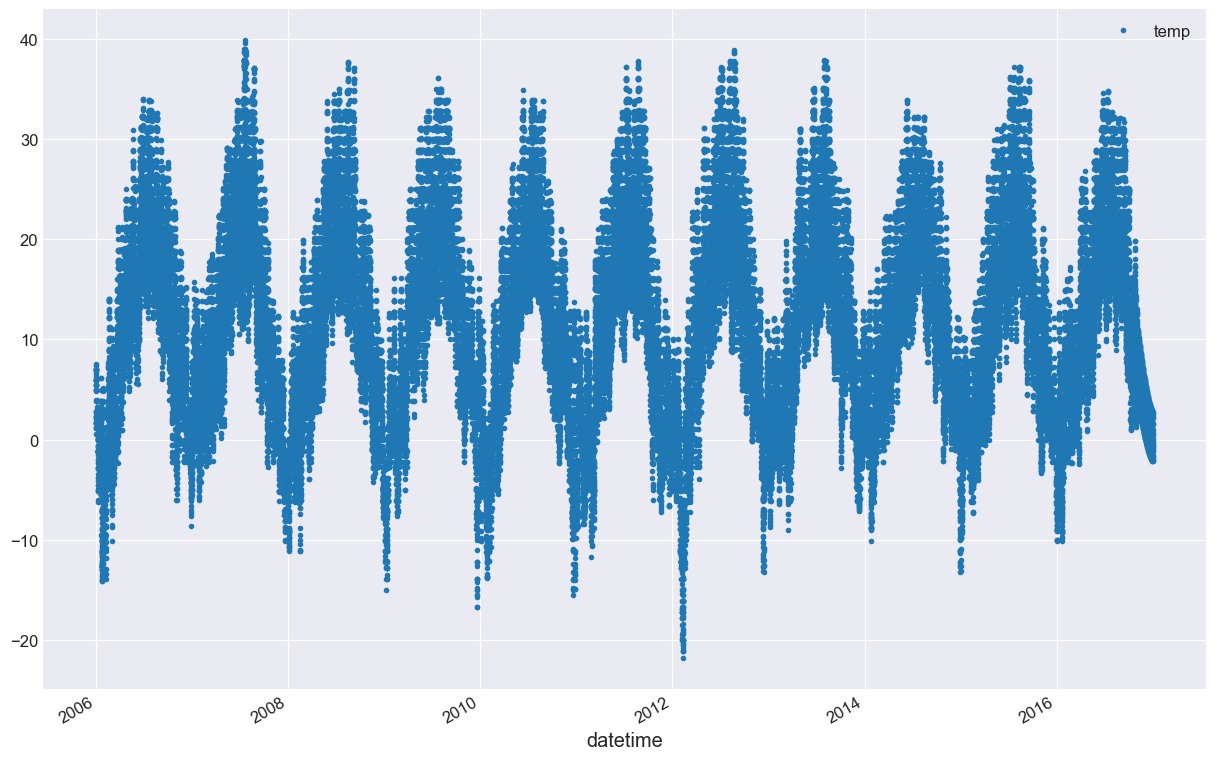

In [9]:
fig,axes = plt.subplots()
temp_df.plot(x = 'datetime',y = 'temp', style = '.',ax = axes)

In [10]:
num_cols = [
 'Temperature (C)',
 'Humidity',
 'Wind Speed (km/h)',
 'Wind Bearing (degrees)',
 'Visibility (km)',
 'Pressure (millibars)',
 
 ]


<h1>Using Temperature and Humidity code</h1>

In [11]:
temp_df = data_df[['datetime','Temperature (C)','Visibility (km)']]
temp_df = temp_df.sort_values('datetime',axis = 0,ascending=True)
temp_df = temp_df.reset_index(drop=True)
temp_df

,datetime,Temperature (C),Visibility (km)
0,2005-12-31 23:00:00+00:00,0.577778,9.9820
1,2006-01-01 00:00:00+00:00,1.161111,9.9015
2,2006-01-01 01:00:00+00:00,1.666667,9.9015
3,2006-01-01 02:00:00+00:00,1.711111,9.9015
4,2006-01-01 03:00:00+00:00,1.183333,9.9015
...,...,...,...
96448,2016-12-31 18:00:00+00:00,0.488889,8.0178
96449,2016-12-31 19:00:00+00:00,0.072222,7.2450
96450,2016-12-31 20:00:00+00:00,-0.233333,9.5795
96451,2016-12-31 21:00:00+00:00,-0.472222,8.4042


In [12]:
temp_df = temp_df.rename({'Temperature (C)' : 'temp',
                         'Visibility (km)':'viz',
                         },axis = 1)
temp_df

,datetime,temp,viz
0,2005-12-31 23:00:00+00:00,0.577778,9.9820
1,2006-01-01 00:00:00+00:00,1.161111,9.9015
2,2006-01-01 01:00:00+00:00,1.666667,9.9015
3,2006-01-01 02:00:00+00:00,1.711111,9.9015
4,2006-01-01 03:00:00+00:00,1.183333,9.9015
...,...,...,...
96448,2016-12-31 18:00:00+00:00,0.488889,8.0178
96449,2016-12-31 19:00:00+00:00,0.072222,7.2450
96450,2016-12-31 20:00:00+00:00,-0.233333,9.5795
96451,2016-12-31 21:00:00+00:00,-0.472222,8.4042


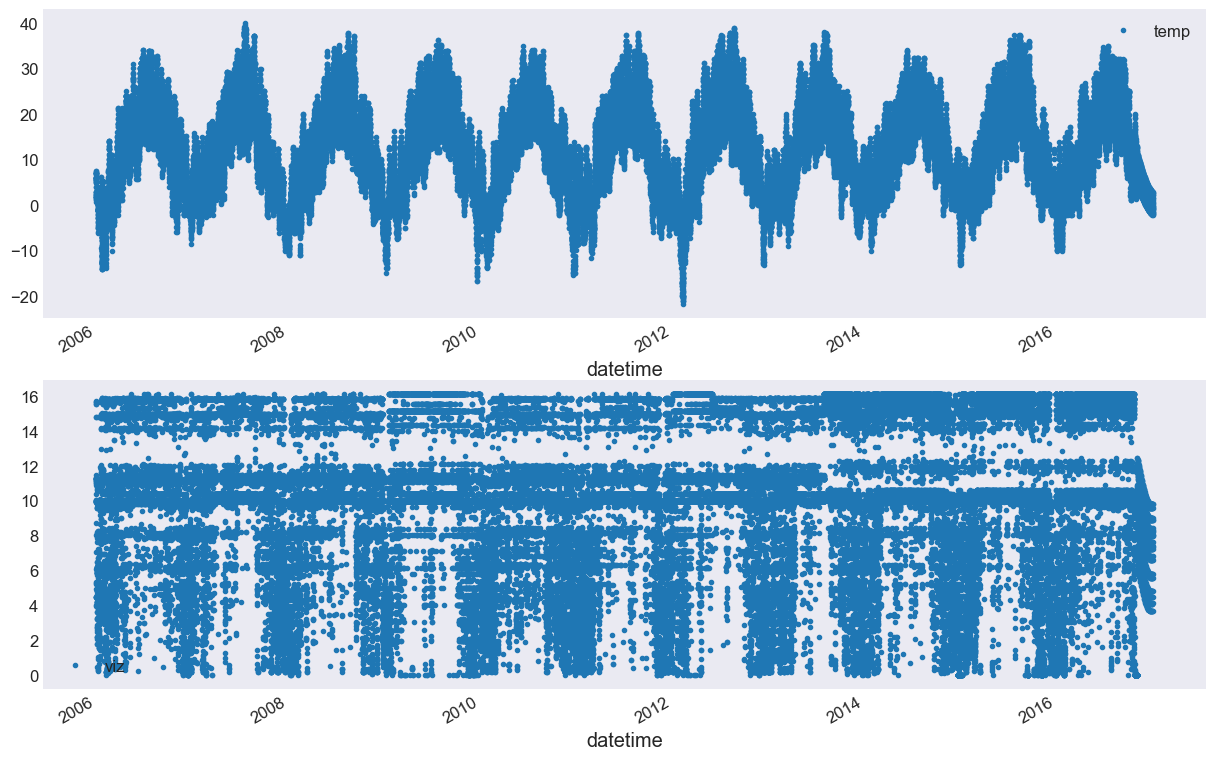

In [14]:
fig,axes = plt.subplots(2,1)
ax = axes[0]
temp_df.plot(x = 'datetime',y = 'temp', style = '.',ax = ax)
ax.grid()
ax = axes[1]
temp_df.plot(x = 'datetime',y = 'viz', style = '.',ax = ax)
ax.grid()


In [15]:
time_step = 24
y_idx = np.arange(time_step,temp_df.shape[0],time_step)
y_idx

array([   24,    48,    72, ..., 96384, 96408, 96432], shape=(4018,))

In [16]:
y_df = temp_df.iloc[y_idx]
y_df.head()

,datetime,temp,viz
24,2006-01-01 23:00:00+00:00,5.422222,15.6492
48,2006-01-02 23:00:00+00:00,1.694444,4.4919
72,2006-01-03 23:00:00+00:00,2.200000,9.5795
96,2006-01-04 23:00:00+00:00,1.666667,9.9015
120,2006-01-05 23:00:00+00:00,1.805556,2.2057


In [17]:
X_df = temp_df.iloc[range(len(y_df)*time_step)]
X_df.shape

(96432, 3)

In [20]:
X_temp = np.reshape(X_df['temp'].to_numpy(),(len(y_df),time_step))
X_viz = np.reshape(X_df['viz'].to_numpy(),(len(y_df),time_step))


X_temp.shape

(4018, 24)

In [21]:
X_temp = X_temp[:,:23]
X_viz = X_viz[:,:23]

# X = np.reshape(X,(X.shape[0],X.shape[1],1))
X_temp.shape

(4018, 23)

In [22]:
X_data = np.stack((X_temp,X_viz),axis = 2) #Sample,timesteps,features
X_data.shape

(4018, 23, 2)

In [23]:
split = int(y_df.shape[0] * (1 - TEST_SIZE))
X_train = X_data[:split]
X_test = X_data[split:]
y_train = y_df['temp'].to_numpy()[:split]
y_test = y_df['temp'].to_numpy()[split:]
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((3214, 23, 2), (804, 23, 2), (3214,), (804,))

In [24]:
#model Creation

h_units = 512
input_shape = (time_step-1,X_train.shape[2])

model = tf.keras.Sequential()
model.add(tf.keras.Input(shape = input_shape))
model.add(tf.keras.layers.SimpleRNN(units = h_units,activation = 'tanh'))
model.add(tf.keras.layers.Dense(1,activation = 'linear'))


In [25]:
metrics =tf.keras.metrics.RootMeanSquaredError()#metrics
loss_fn = tf.keras.losses.MeanSquaredError() #loss function
optimizer = tf.keras.optimizers.Adam(learning_rate = ALPHA) #optimizer

In [26]:
#call backs
PATIENCE = 20
LR_FACTOR =0.1 
LR_PATIENCE = 5
MIN_LR = 1e-6


tb_callback = tf.keras .callbacks.TensorBoard(log_dir='logs')

es_callback = tf.keras.callbacks.EarlyStopping(monitor= 'val_loss',
                                              patience=PATIENCE,
                                              verbose = 1,
                                              restore_best_weights=True,
)

chkpt_filepath =' modelDir/subDir/all_in.keras'
chkpt_callback = tf.keras.callbacks.ModelCheckpoint(
    chkpt_filepath,
    monitor= 'val_loss',
    verbose = 1,
    save_best_only = True,
)

lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
   monitor='val_loss',
    factor= LR_FACTOR,
    patience = LR_PATIENCE,
    verbose = 1,
    mode = 'auto',
    min_lr=MIN_LR
)



In [27]:
model.compile(optimizer = optimizer,
             loss = loss_fn,
             metrics = [metrics])

<h1>Training</h1>

In [28]:
history = model.fit(X_train,y_train,
                    validation_data=[X_test,y_test],
                    callbacks = [es_callback,lr_callback],
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS)

Epoch 1/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 5.7328 - root_mean_squared_error: 2.3943 - val_loss: 1.3725 - val_root_mean_squared_error: 1.1715 - learning_rate: 0.0010
Epoch 2/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 1.3870 - root_mean_squared_error: 1.1777 - val_loss: 1.0985 - val_root_mean_squared_error: 1.0481 - learning_rate: 0.0010
Epoch 3/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 1.2991 - root_mean_squared_error: 1.1398 - val_loss: 1.1397 - val_root_mean_squared_error: 1.0675 - learning_rate: 0.0010
Epoch 4/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 1.2147 - root_mean_squared_error: 1.1021 - val_loss: 1.0509 - val_root_mean_squared_error: 1.0251 - learning_rate: 0.0010
Epoch 5/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 1.1606 - root_mean_squared_error: 1.0773 - val_loss: 0.9893 - val_root_mean_squared_error: 0.9947 - learning_rate: 0.0010
Epoch 6/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 1.1194 - root_mean

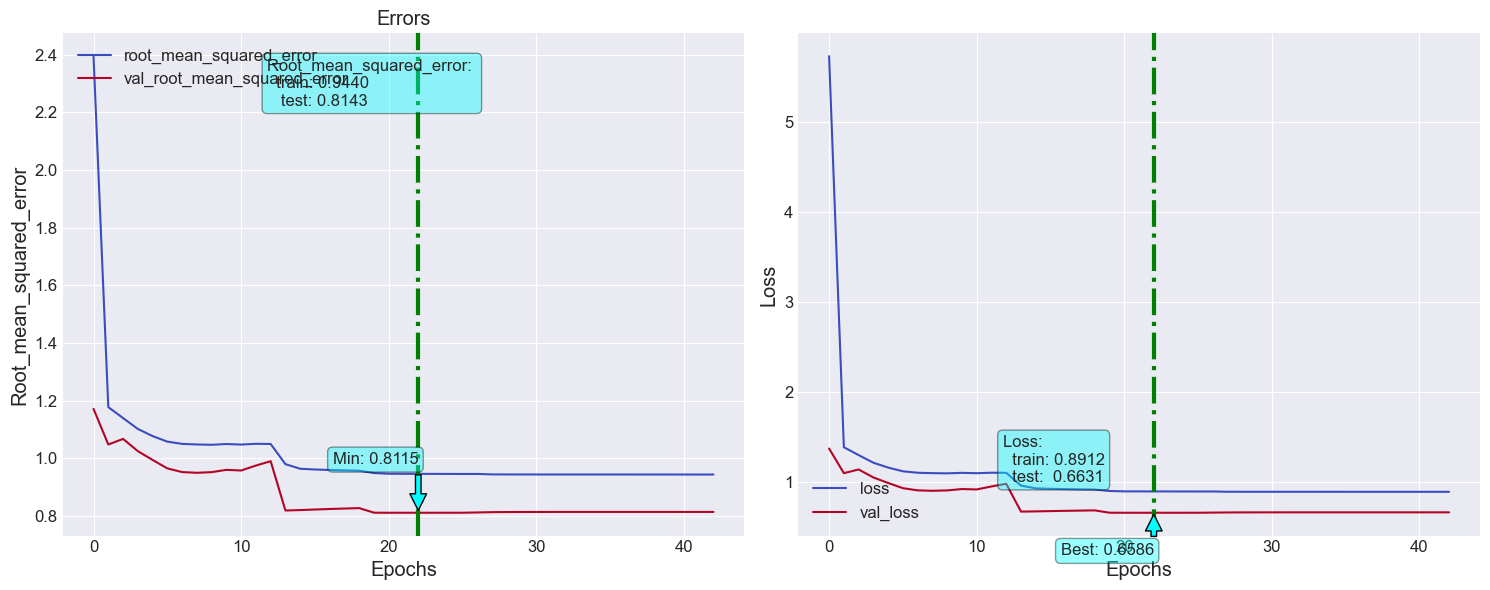

In [30]:
loss_df = pd.DataFrame(history.history)
fn_plot_tf_hist(loss_df)